## FEATURE SCALING

Feature Scaling is the process of bringing all numerical features to a similar scale so that no feature dominates others because of its larger values.

Two Types -> 1. Standardization   2. Normalization

1. Standardization (Z-Score Normalization)

Formula:

z= (x−μ)/σ

Where:

x = original value
μ = mean
σ = standard deviation

After standardization:

Mean = 0
Standard deviation = 1

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:

dataset = pd.read_csv(r"C:\Users\SHAMSHER\Downloads\student-lifestyle-and-stress-dataset.csv")
dataset.head(3)


,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1


In [18]:
dataset.isnull().sum()

Student_Type          1252
Sleep_Hours           1333
Study_Hours           1277
Social_Media_Hours    1312
Attendance               0
Exam_Pressure         1270
Family_Support        1291
Month                    0
Stress_Level             0
dtype: int64

In [17]:
dataset['Attendance'].fillna(dataset['Attendance'].mean(),inplace=True)
dataset['Month'].fillna(dataset['Month'].mean(),inplace=True)

C:\Users\SHAMSHER\AppData\Local\Temp\ipykernel_5828\3307975582.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Attendance'].fillna(dataset['Attendance'].mean(),inplace=True)
C:\Users\SHAMSHER\AppData\Local\Temp\ipykernel_5828\3307975582.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

C:\Users\SHAMSHER\AppData\Local\Temp\ipykernel_5828\3975375322.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Attendance'])


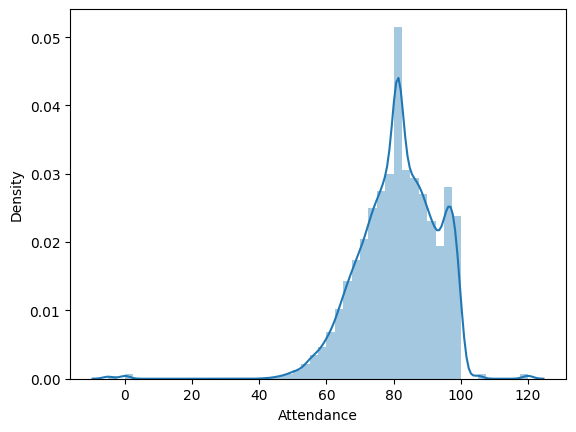

In [19]:
sns.distplot(dataset['Attendance'])
plt.show()

In [20]:
dataset.describe()

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
count,24167.000000,24223.000000,24188.000000,25500.000000,24230.000000,24209.000000,25500.000000,25500.000000
mean,6.458948,4.696477,3.555614,81.270961,5.369748,5.798298,6.500992,0.299882
std,1.504228,2.240148,1.901528,11.739592,2.394003,2.232371,3.365102,0.458215
min,2.008586,-1.433434,0.000040,-5.000000,1.000000,1.000000,1.000000,0.000000
25%,5.438360,3.078230,2.152249,74.283316,4.000000,4.000000,4.000000,0.000000
50%,6.542566,4.538138,3.500709,81.270961,5.000000,6.000000,6.500992,0.000000
75%,7.531571,6.135670,4.864312,89.583237,7.000000,7.000000,9.000000,1.000000
max,9.997527,22.444460,9.962134,120.000000,10.000000,10.000000,12.000000,1.000000


Scalling through sklearn

In [21]:
from sklearn.preprocessing import StandardScaler

In [23]:
ss = StandardScaler()
ss.fit(dataset[['Attendance']])

StandardScaler()

In [25]:
dataset['Attendance_ss'] =  pd.DataFrame(ss.transform(dataset[['Attendance']]),columns=['x'])

In [26]:
dataset.head(3)

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level,Attendance_ss
0,school,6.868702,1.711722,3.176942,81.270961,8.0,7.0,2.0,1,0.000000
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1,1.082470
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1,-1.435317


In [27]:
dataset.describe()

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level,Attendance_ss
count,24167.000000,24223.000000,24188.000000,25500.000000,24230.000000,24209.000000,25500.000000,25500.000000,2.550000e+04
mean,6.458948,4.696477,3.555614,81.270961,5.369748,5.798298,6.500992,0.299882,-1.791682e-16
std,1.504228,2.240148,1.901528,11.739592,2.394003,2.232371,3.365102,0.458215,1.000020e+00
min,2.008586,-1.433434,0.000040,-5.000000,1.000000,1.000000,1.000000,0.000000,-7.348863e+00
25%,5.438360,3.078230,2.152249,74.283316,4.000000,4.000000,4.000000,0.000000,-5.952321e-01
50%,6.542566,4.538138,3.500709,81.270961,5.000000,6.000000,6.500992,0.000000,0.000000e+00
75%,7.531571,6.135670,4.864312,89.583237,7.000000,7.000000,9.000000,1.000000,7.080688e-01
max,9.997527,22.444460,9.962134,120.000000,10.000000,10.000000,12.000000,1.000000,3.299075e+00


C:\Users\SHAMSHER\AppData\Local\Temp\ipykernel_5828\3496005014.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Attendance'])
C:\Users\SHAMSHER\AppData\Local\Temp\ipykernel_5828\3496005014.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Attendance_ss'])


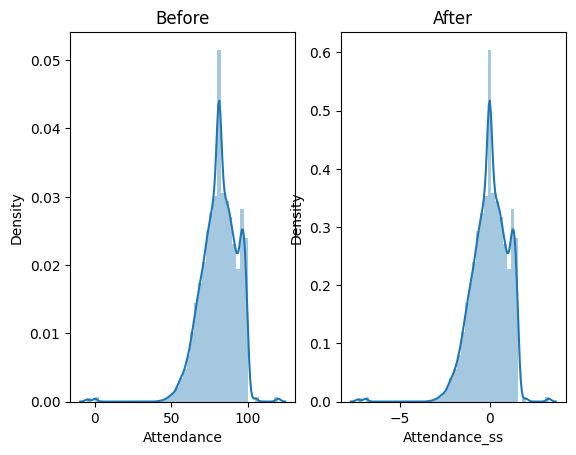

In [33]:
plt.subplot(1,2,1)
plt.title("Before")
sns.distplot(dataset['Attendance'])

plt.subplot(1,2,2)
plt.title("After")
sns.distplot(dataset['Attendance_ss'])
plt.show()

Data shrink but Nature remain same

This is called Standardlization Scaling

# Normalization (Min-Max Scaling)

Normalization is a feature scaling technique that transforms numerical values into a fixed range, usually 0 to 1.

Formula
Xnew = (x - Xmin)/(Xmax−Xmin)

Where:

X = Original value
Xmin = Minimum value
Xmax = Maximum value
Example

Original values: [20, 40, 60, 80, 100]

After normalization:

[0, 0.25, 0.5, 0.75, 1]

In [35]:

dataset = pd.read_csv(r"C:\Users\SHAMSHER\Downloads\assessments.csv")
dataset.head(3)


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0


In [36]:
dataset.isnull().sum()

code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
date                 11
weight                0
dtype: int64

In [37]:
dataset.describe()

,id_assessment,date,weight
count,206.000000,195.000000,206.000000
mean,26473.975728,145.005128,20.873786
std,10098.625521,76.001119,30.384224
min,1752.000000,12.000000,0.000000
25%,15023.250000,71.000000,0.000000
50%,25364.500000,152.000000,12.500000
75%,34891.750000,222.000000,24.250000
max,40088.000000,261.000000,100.000000


C:\Users\SHAMSHER\AppData\Local\Temp\ipykernel_5828\4005104924.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['id_assessment'])


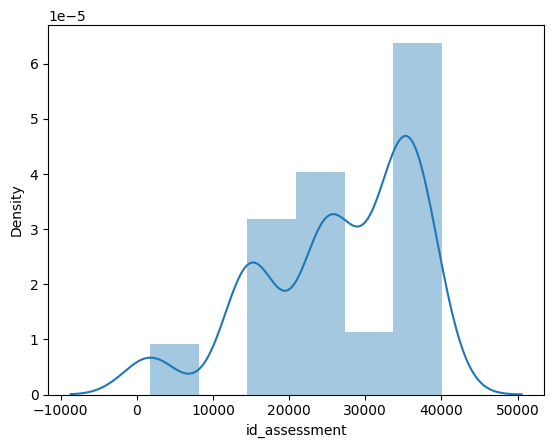

In [38]:
sns.distplot(dataset['id_assessment'])
plt.show()

In [39]:
from sklearn.preprocessing import MinMaxScaler

In [42]:
ms = MinMaxScaler()
ms.fit(dataset[['id_assessment']])

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](1,)",[40088.]
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](1,)",[1752.]
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](1,)",[38336.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['id_assessment']
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](1,)",[-0.05]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,206


In [44]:
dataset["id_assessment_min"] = ms.transform(dataset[['id_assessment']])

In [45]:
dataset.head(3)

,code_module,code_presentation,id_assessment,assessment_type,date,weight,id_assessment_min
0,AAA,2013J,1752,TMA,19.0,10.0,0.000000
1,AAA,2013J,1753,TMA,54.0,20.0,0.000026
2,AAA,2013J,1754,TMA,117.0,20.0,0.000052


C:\Users\SHAMSHER\AppData\Local\Temp\ipykernel_5828\2657165385.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['id_assessment'])
C:\Users\SHAMSHER\AppData\Local\Temp\ipykernel_5828\2657165385.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['id_assessment_min'])


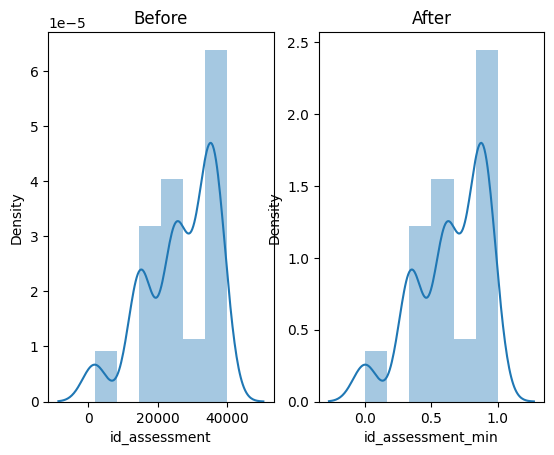

In [49]:

plt.subplot(1,2,1)
plt.title("Before")
sns.distplot(dataset['id_assessment'])

plt.subplot(1,2,2)
plt.title("After")
sns.distplot(dataset['id_assessment_min'])
plt.show()

Nature same but data shrink